In [1]:
import tensorflow as tf

# TensorFlow / NumPy / Python에서 사용하는
# 난수 생성 시드(seed)를 42로 고정합니다.
# 같은 시드를 사용하면 난수 생성의 시작 상태가 동일해집니다.
tf.keras.utils.set_random_seed(42)

# GPU는 병렬 연산을 수행하기 때문에
# 연산 순서가 실행 시점마다 달라질 수 있습니다.
# 이로 인해 같은 코드라도 결과가 미세하게 달라지는
# 비결정적(non-deterministic) 연산이 발생할 수 있습니다.
# 따라서 시드를 고정하더라도 100% 동일한 결과가
# 항상 보장되지는 않습니다.

# TensorFlow 연산에서 발생하는 비결정성을 최소화하기 위해
# 가능한 한 연산 순서와 알고리즘을 고정하도록 설정합니다.
tf.config.experimental.enable_op_determinism()

 ---
데이터 준비

In [2]:
import keras
from sklearn.model_selection import train_test_split

(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

train_scaled = train_input / 255.0

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

 ---
모델을 만드는 간단한 함수 정의
- 매개변수를 이용해서 은닉층 뒤에 또 하나의 층을 추가할 수 있습니다.

In [3]:
def model_fn(a_layer=None):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(28, 28)))
    model.add(keras.layers.Flatten())
    model.add(keras.layers.Dense(100, activation='relu', name='h1'))
    if a_layer:
        model.add(a_layer)
    model.add(keras.layers.Dense(10, activation='softmax', name='out1'))
    return model

In [4]:
model = model_fn()

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h1 (Dense)                      │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out1 (Dense)                    │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# verbose=0 은 출력이 되지 않습니다.
# verbose=1 (기본값) 은 프로그레스 바 출력, 배치 단위 진행 상황 표시
# verbose=2는 epoch 단위 요약만 출력, 배치 진행바 없습니다.
history = model.fit(train_scaled, train_target, epochs=5, verbose=0)

 ---
<keras.src.callbacks.history.History at 0x1e178943620>

In [6]:
# history 객체에는 측정갓ㅂ이 담겨 있는 history 딕셔너리가 들어 있습니다.
print(history.history.keys())
# 정확도와 손실의 정보가 포함되어 있습니다.
# 정확도는 model.compile(... .metrics=['accuracy]) 를 추가했기 때문에 history 속성에 포함되었습니다.

dict_keys(['accuracy', 'loss'])


- loss : 예측값과 실제값의 차이를 나타낸느 값 (작을수록 좋음)
- accuracy : 젼체 데이터 중 맞게 예측한 비율 (클수록 좋음)

In [7]:
# epoch 마다 정확도와 손실 정보가 들어있습니다.
print(history.history['accuracy'])
print(history.history['loss'])

[0.8112499713897705, 0.8586458563804626, 0.8727708458900452, 0.8809166550636292, 0.8888333439826965]
[0.5311373472213745, 0.3905622661113739, 0.35328060388565063, 0.3294256031513214, 0.31286561489105225]


 ---
에포크당 손실 값

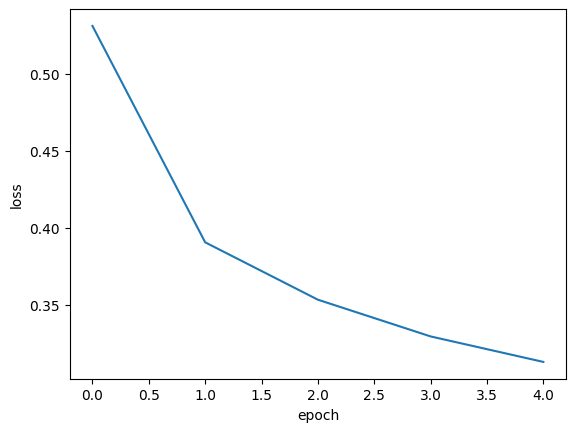

In [8]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

 ---
에포크당 정확도

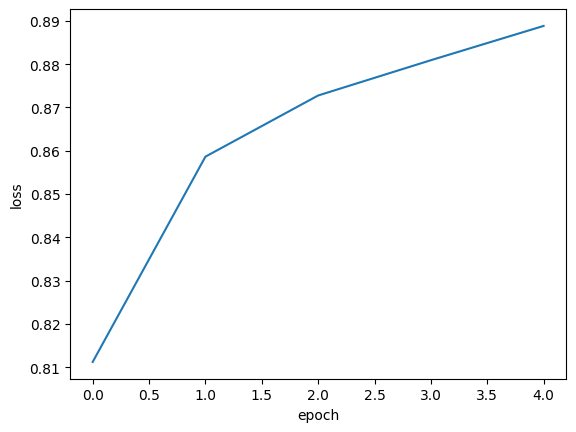

In [9]:
plt.plot(history.history['accuracy'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

 ---
에포크 횟수를 20으로 늘리고 모델 훈련 후 손실 그래프

In [10]:
# epochs=20 일때의 손실 그래프를 그려 보겠습니다.
model2 = model_fn()
model2.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model2.fit(train_scaled, train_target, epochs=20, verbose=0)

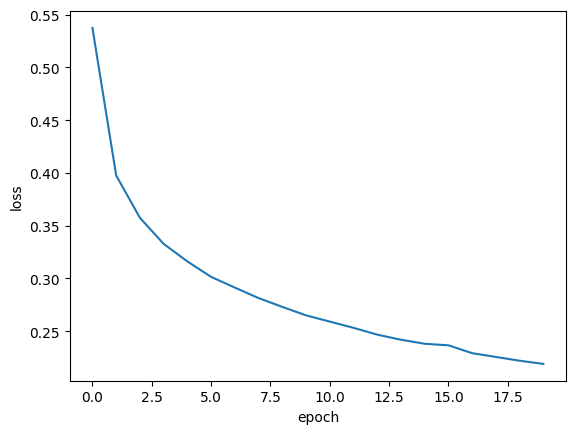

In [11]:
plt.plot(history.history['loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

 ---
## 검증 손실

In [12]:
# 검증용 데이터 확인
print(val_scaled.shape)
print(val_target.shape)

(12000, 28, 28)
(12000,)


In [13]:
model3 = model_fn()
model3.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# validation_data=(val_scaled, val_target) 는 모델 학습 중에 검증 데이터(validation set)를 사용하겠다는 의미입니다.
# 훈련(training)에 사용하지 않는 데이터로 매 epoch마다 모델 성능을 평가합니다.
history = model3.fit(train_scaled, train_target, epochs=20, verbose=0,
                     validation_data=(val_scaled, val_target))

In [14]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


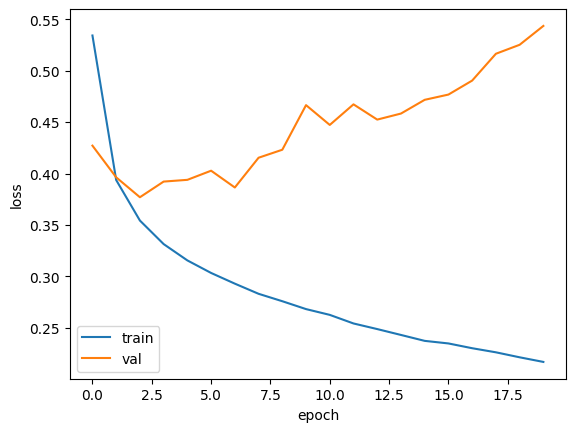

In [15]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

# 매 에포크마다 'val_loss'의 값이 감소하다가 갑자기 계속 증가하는 모습이 보입니다.
# 매 에포크마다 train은 손실 값이 감소하고 있습니다.
# 이런 상태가 과대적합입니다. 즉 훈련 데이터에는 점점 더 잘 맞지만,
# 새로운 데이터에 대한 예측 성능은 오히려 나빠지는 상태입니다.

 ---
## 옵티마이저 하이퍼파라미터 변경

옵티마이저 하이퍼파라미터를 변경해서 과대 적합을 완화시킬 수 있는지 알아보겠습니다.

optimizer='adam'으로 변경

In [16]:
model4 = model_fn()
model4.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

history = model4.fit(train_scaled, train_target, epochs=20, verbose=0,
                     validation_data=(val_scaled, val_target))

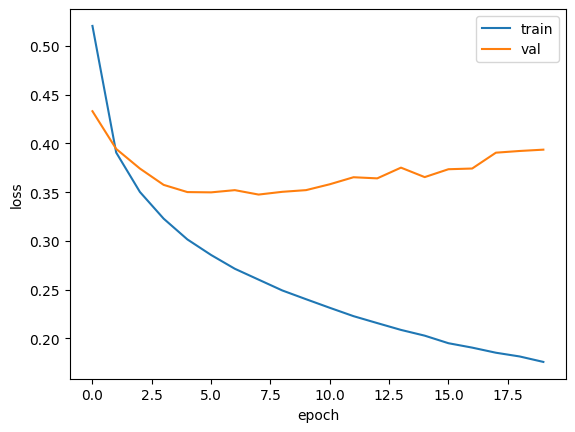

In [17]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

 ---
## 학습률 변경

In [18]:
model5 = model_fn()

adam = keras.optimizers.Adam(learning_rate=0.0005)
model5.compile(optimizer=adam, loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

history = model5.fit(train_scaled, train_target, epochs=20, verbose=0,
                     validation_data=(val_scaled, val_target))

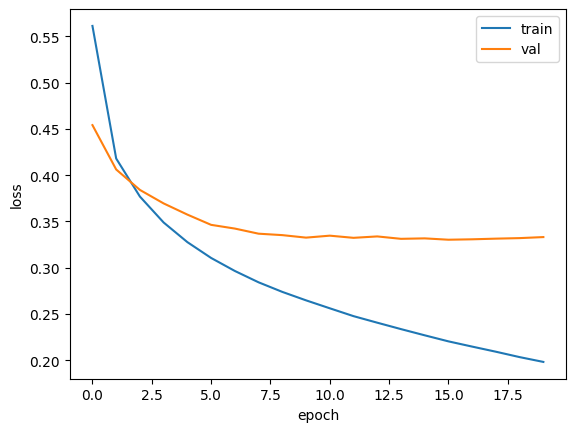

In [19]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

 ---
## 드롭아웃

- 훈련 과정에서 층에 있는 일부 뉴런을 랜덤하게 꺼서(뉴런의 출력을 0으로 만들어) 과대 적합을 규제할 수 있습니다.

- Dropout은 학습하는 층이 아니라 출력 일부를 랜덤하게 0으로 만드는 규제(regularization) 층입니다.

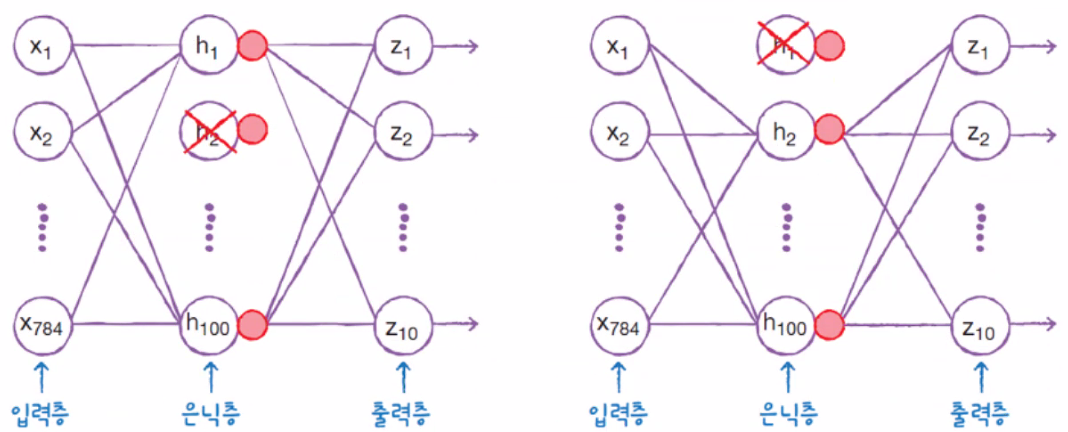

In [20]:
model6 = model_fn(keras.layers.Dropout(0.3)) # 30% 드롭아웃

model6.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h1 (Dense)                      │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out1 (Dense)                    │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

은닉층 뒤에 추가된 드롭아웃 층은 훈련되는 파라미터가 없습니다.

또한 입력과 출력의 결과가 같습니다.

일부 뉴런의 출력을 0으로 만들지만 전체 출력 배열의 크기를 바꾸지 않습니다.

---

In [21]:
model6.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

history = model6.fit(train_scaled, train_target, epochs=20, verbose=0,
                     validation_data=(val_scaled, val_target))

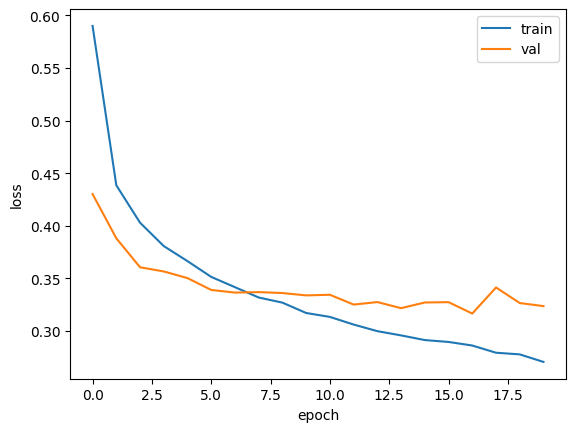

In [22]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

과대 적합이 확실히 줄었습니다. 열두 번째 에포크 정도에서 검증 손실의 감소가 멈추지만 크게 상승하지 않고 어느 정도 유지 되고 있습니다.

이 모델은 20번 에포크 동안 훈련을 했기 때문에 다소 과대 적합이 되었습니다.

에포크 횟수를 11로 지정하고 다시 훈련합니다.

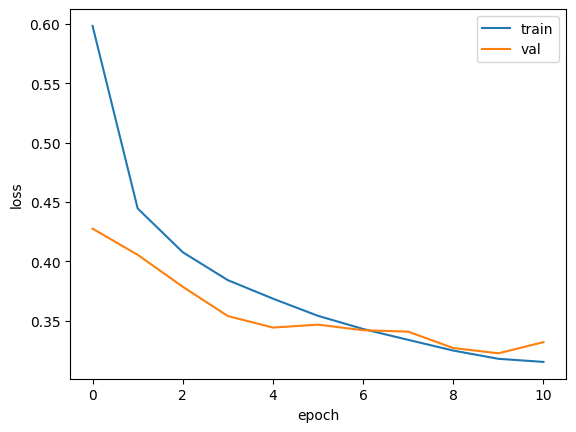

In [23]:
model7 = model_fn(keras.layers.Dropout(0.3))
model7.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

history = model7.fit(train_scaled, train_target, epochs=11, verbose=0,
                     validation_data=(val_scaled, val_target))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()

 ---
## 모델 저장과 복원

In [24]:
model8 = model_fn(keras.layers.Dropout(0.3))
model8.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

history = model8.fit(train_scaled, train_target, epochs=11, verbose=0,
                     validation_data=(val_scaled, val_target))

In [25]:
# 현재 모델(model8)의 전체 정보를 파일로 저장합니다.
# 저장되는 내용 : 모델 구조 + 학습된 가중치 + 학습 설정(optimizer, loss 등)
# 나중에 load_model()을 사용하여 동일한 모델을 다시 불러올 수 있습니다.
model8.save('model8-whole.keras')

In [26]:
# 모델의 가중치(weight)와 편향(bias) 파라미터만 파일로 저장합니다.
# 모델 구조는 저장되지 않습니다.
# 나중에 동일한 구조의 모델을 만든 후 load_weight()로 가중치를 불러와 사용할 수 있습니다.
model8.save_weights('model8.weights.h5')

 ---
## 훈련하지 않은 새로운 모델

In [27]:
# 훈련을 하지 않은 새로운 모델을 만듭니다.
model9 = model_fn(keras.layers.Dropout(0.3))

# 훈련된 모델 파라미터 파일을 읽어서 사용합니다.
model9.load_weights('model8.weights.h5')

# load_weights() 메서드를 사용하려면 save_weights()로 저장했던 모델과 정확히 같은 구조를 가져야 합니다.

In [28]:
import numpy as np

# 검증 데이터(val_scaled)를 모델에 입력하여 각 클래스별 예측 확률 값을 계산합니다.
result = model9.predict(val_scaled)
print(result)
print(result.shape)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 533us/step
[[1.2881780e-10 4.9834432e-17 1.8400240e-11 ... 6.9494078e-08
  9.9996281e-01 2.6474368e-15]
 [7.2335391e-09 1.4024439e-12 4.1898698e-09 ... 5.8415100e-12
  9.9999988e-01 3.1908926e-12]
 [8.5597387e-13 1.8791355e-12 8.9379001e-15 ... 9.9983656e-01
  1.1979828e-09 7.4267456e-07]
 ...
 [2.1753222e-07 3.7283185e-10 1.0713760e-07 ... 5.0552746e-08
  9.9999869e-01 5.3785598e-09]
 [5.7357070e-09 7.7206875e-15 8.8435348e-09 ... 3.8870475e-13
  1.0000000e+00 4.4926596e-16]
 [8.4489942e-02 2.3925134e-06 2.8360602e-03 ... 2.3945235e-03
  7.2710180e-05 3.5999265e-01]]
(12000, 10)


 ---

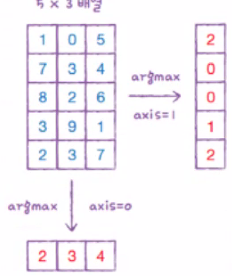

axis=0이면 행을 따라 각 열의 최댓값의 인덱스를 선택하고
axis=1이면 열을 따라 각 행의 최댓값의 인덱스를 선택하고
axis=-1이면 배열의 마지막 차원을 선택합니다.

우리가 흔히 말하는 2차원 배열은 (행, 열)의 구조를 가집니다.

- 첫 번째 차원 (axis=0): 행(Row) 방향 $\rarr$ 위에서 아래로
- 두 번째 차원 (axis=1): 열(Column) 방향 $\rarr$ 왼쪽에서 오른쪽으로  
여기서 마지막 차원은 두 번째 차원인 **axis=1**이 됩니다.

In [29]:
# 모델의 예측 확률값 중 마지막 차원(각 샘플의 클래스 확률들)에서 가장 큰 값의 인덱스를 추출합니다.
val_labels = np.argmax(model9.predict(val_scaled), axis=-1)

# 예측한 번호(val_labels)와 실제 정답(val_targete)이 일치하는 비율(평균)을 구해 정확도를 계산합니다.
print(np.mean(val_labels == val_target))

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 480us/step
0.8834166666666666


 ---
### 모델 전체를 읽어서 검증 세트의 정확도 출력

In [30]:
from typing import Any

model10: Any = keras.models.load_model('model8-whole.keras')

model10.evaluate(val_scaled, val_target)
# 총 12000개 / 배치크기(32) = 375

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step - accuracy: 0.8834 - loss: 0.3218


[0.3217598795890808, 0.8834166526794434]

 ---
## 콜백

- 훈련 과정 중간에 어떤 작업을 수행할 수 있도록 하는 객체입니다.
- fit() 메서드의 callbacks 매개변수에 리스트로 전달하여 사용합니다.

In [32]:
model11 = model_fn(keras.layers.Dropout(0.3))
model11.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('best-model11.keras', # 저장할 파일명
                                                save_best_only=True)  # 가장 좋은 성능(최소 val_loss) 모델만 저장

model11.fit(train_scaled, train_target, epochs=20, verbose=0,
            validation_data=(val_scaled, val_target),
            callbacks=[checkpoint_cb])

In [ ]:
model12: Any = keras.models.load_model('best-model11.keras')

model12.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 602us/step - accuracy: 0.8833 - loss: 0.3209


[0.32086876034736633, 0.8833333253860474]

 ---
### 조기 종료

- 과대적합이 시작되기 전에 훈련을 미리 중지하는 것을 조기 종료라고 합니다.
- 조기 종료는 훈련 에포크 횟수를 제한하는 역할
- 모델이 과대적합되는 것을 막아 주기 때문에 규제 방법 중 하나로 생각할 수 있습니다.
- 계산 비용과 시간을 절약할 수 있습니다.

In [37]:
model13 = model_fn(keras.layers.Dropout(0.3))
model13.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('best-model13.keras',
                                                save_best_only=True)

# patience = 2 : 2번 연속 검증 점수가 향상 되지 않으면 훈련을 중지합니다.
# restore_best_weights=True : 가장 낮은 검증 손실(val_loss)을 기록한 epoch의 가중치로 복원합니다.
early_stopping_cb = keras.callbacks.EarlyStopping(patience=2,
                                                  restore_best_weights=True)

history = model13.fit(train_scaled, train_target, epochs=20, verbose=0,
                      validation_data=(val_scaled, val_target),
                      callbacks=[checkpoint_cb, early_stopping_cb])

In [38]:
print(early_stopping_cb.stopped_epoch)

12


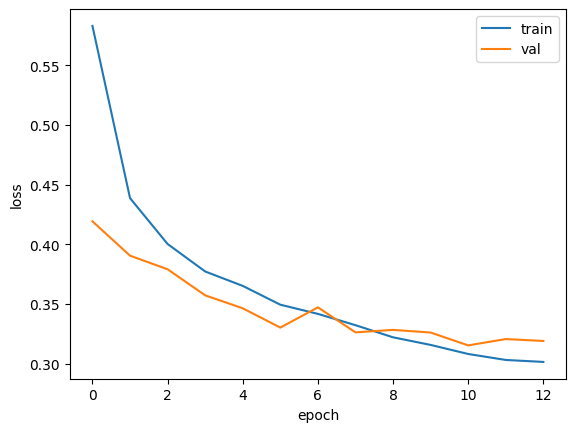

In [39]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()